In [ ]:
# pip install xarray netCDF4 pandas numpy scikit-learn xgboost joblib

import numpy as np
import pandas as pd
import xarray as xr
from xgboost import XGBRegressor
from sklearn.metrics import r2_score, mean_absolute_error
import joblib


In [1]:
import glob
import xarray as xr

PATH = "/Users/lb962/Documents/GitHub/ESL/data/ml4_removed/*.nc"

# Get sorted list of files
files = sorted(glob.glob(PATH))

# Open each file into a list of datasets
datasets = [xr.open_dataset(f) for f in files]

# Example: inspect or process one
for i, ds in enumerate(datasets):
    print(f"File {i}: {files[i]}")
    print(ds)

# If you want them in memory:
datasets = [ds.load() for ds in datasets]

File 0: /Users/lb962/Documents/GitHub/ESL/data/ml4_removed/station_1.nc
<xarray.Dataset>
Dimensions:              (valid_time: 750192)
Coordinates:
    station              int64 ...
  * valid_time           (valid_time) datetime64[ns] 1940-01-01 ... 2025-07-3...
    latitude             float64 ...
    longitude            float64 ...
    station_latitude     float64 ...
    station_longitude    float64 ...
    year                 (valid_time) int64 ...
Data variables: (12/15)
    u10                  (valid_time) float32 ...
    v10                  (valid_time) float32 ...
    d2m                  (valid_time) float32 ...
    t2m                  (valid_time) float32 ...
    msl                  (valid_time) float32 ...
    sst                  (valid_time) float32 ...
    ...                   ...
    mwp                  (valid_time) float32 ...
    swh                  (valid_time) float32 ...
    sea_level            (valid_time) float32 ...
    tide                 (valid_time

In [7]:
ds = xr.concat(datasets, dim="time")

In [ ]:
# ================= Q–Q analysis: per-station best model =================
import os
import numpy as np
import xarray as xr
import scipy.stats as st
import warnings
import matplotlib.pyplot as plt
from numpy.linalg import lstsq

OUTPUT_DIR = "/Users/lb962/Documents/GitHub/ESL/data/Q-Q_results"
VAR_NAME   = "residual"
STN_DIM    = "station"
MIN_N      = 20
PROBS      = np.linspace(0.01, 0.99, 99)

DISTRIBUTIONS = [
    ("lognorm", st.lognorm,      {"require_pos": True}),   # params: (s, loc, scale)
    ("gamma",   st.gamma,        {"require_pos": True}),   # params: (a, loc, scale)
    ("gev",     st.genextreme,   {"require_pos": False}),  # params: (c, loc, scale)
]

os.makedirs(OUTPUT_DIR, exist_ok=True)

def station_label(ds, i, station_dim=STN_DIM):
    # Prefer ID-ish fields if present
    for key in ("station_id","id","wmo_id","name"):
        if key in ds.coords and ds[key].ndim==1 and ds[key].sizes[station_dim]>i:
            return str(np.array(ds[key].isel({station_dim:i}).values).item())
        if key in ds and ds[key].ndim==1 and ds[key].sizes[station_dim]>i:
            return str(np.array(ds[key].isel({station_dim:i}).values).item())
    # else use the coord value or index
    if station_dim in ds.coords:
        try:
            return str(np.array(ds[station_dim].isel({station_dim:i}).values).item())
        except Exception:
            pass
    return f"{i:05d}"

def qq_metrics(x, dist, params, probs=PROBS):
    y = np.quantile(x, probs)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        x_theor = dist.ppf(probs, *params)
    m = np.isfinite(x_theor) & np.isfinite(y)
    if m.sum() < 3:
        return (np.nan, np.nan, np.nan, np.nan)
    X = np.column_stack([x_theor[m], np.ones(m.sum())])
    a, b = lstsq(X, y[m], rcond=None)[0]  # slope, intercept
    yhat = a * x_theor[m] + b
    ss_res = np.sum((y[m] - yhat) ** 2)
    ss_tot = np.sum((y[m] - y[m].mean()) ** 2)
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan
    rmse = np.sqrt(np.mean((y[m] - yhat) ** 2))
    return (a, b, r2, rmse)

def fit_params(dist_name, dist_obj, x):
    # Domain guard for positive-only distributions
    x_fit = x
    if dist_name in ("lognorm","gamma"):
        x_fit = x[x > 0]
        if x_fit.size < MIN_N:
            return None, None
    if x_fit.size < MIN_N:
        return None, None
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            params = dist_obj.fit(x_fit)
        return x_fit, params
    except Exception:
        return None, None

def save_best_qq_plot(x_fit, dist_name, dist_obj, params, r2, out_png, title_prefix=""):
    # empirical & theoretical quantiles
    y = np.quantile(x_fit, PROBS)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        xq = dist_obj.ppf(PROBS, *params)
    m = np.isfinite(xq) & np.isfinite(y)
    if m.sum() < 3:
        return
    plt.figure(figsize=(5.2,5.2))
    plt.scatter(xq[m], y[m], s=12, alpha=0.9)
    lo = np.nanmin([xq[m].min(), y[m].min()])
    hi = np.nanmax([xq[m].max(), y[m].max()])
    plt.plot([lo, hi], [lo, hi], linewidth=1.2)  # 45° line
    plt.xlabel("Theoretical quantiles")
    plt.ylabel("Empirical quantiles")
    plt.title(f"{title_prefix}Q–Q: {dist_name} (R²={r2:.3f})")
    plt.tight_layout()
    plt.savefig(out_png, dpi=150)
    plt.close()

def save_station_csv(path, i, label, best_name, best_r2, best_params,
                     per_model_results):
    # per_model_results: dict name -> {"r2":..., "params":tuple or None}
    import csv
    with open(path, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["station_index","station_label","best_model","best_r2","best_params",
                    "lognorm_r2","lognorm_params","gamma_r2","gamma_params","gev_r2","gev_params"])
        row = [
            i, label, best_name,
            f"{best_r2:.6f}" if np.isfinite(best_r2) else "",
            str(best_params) if best_params is not None else "",
            f"{per_model_results['lognorm']['r2']:.6f}" if np.isfinite(per_model_results['lognorm']['r2']) else "",
            str(per_model_results['lognorm']['params']) if per_model_results['lognorm']['params'] is not None else "",
            f"{per_model_results['gamma']['r2']:.6f}"   if np.isfinite(per_model_results['gamma']['r2']) else "",
            str(per_model_results['gamma']['params'])   if per_model_results['gamma']['params'] is not None else "",
            f"{per_model_results['gev']['r2']:.6f}"     if np.isfinite(per_model_results['gev']['r2']) else "",
            str(per_model_results['gev']['params'])     if per_model_results['gev']['params'] is not None else "",
        ]
        w.writerow(row)

# --------- main loop over stations ----------
n_stations = ds.sizes[STN_DIM]
for i in range(n_stations):
    x = ds[VAR_NAME].isel({STN_DIM: i}).values
    x = x[np.isfinite(x)]
    if x.size < MIN_N:
        # still write a stub CSV to know it was skipped
        label = station_label(ds, i)
        csv_path = os.path.join(OUTPUT_DIR, f"station_{label}.csv")
        save_station_csv(csv_path, i, label, "", np.nan, None,
                         {"lognorm":{"r2":np.nan,"params":None},
                          "gamma":{"r2":np.nan,"params":None},
                          "gev":{"r2":np.nan,"params":None}})
        continue

    per_model = {}
    r2_list = []
    xfit_for_best = None
    best_name = None
    best_params = None
    best_r2 = np.nan

    # fit each distribution
    for name, dist_obj, meta in DISTRIBUTIONS:
        x_fit, params = fit_params(name, dist_obj, x)
        if x_fit is None:
            per_model[name] = {"r2": np.nan, "params": None, "obj": dist_obj, "x_fit": None}
            r2_list.append(np.nan)
            continue
        slope, intercept, r2, rmse = qq_metrics(x_fit, dist_obj, params, probs=PROBS)
        per_model[name] = {"r2": r2, "params": params, "obj": dist_obj, "x_fit": x_fit}
        r2_list.append(r2)

    # pick best by R²
    if np.isfinite(r2_list).any():
        best_idx = int(np.nanargmax(r2_list))
        best_name = DISTRIBUTIONS[best_idx][0]
        best_r2 = per_model[best_name]["r2"]
        best_params = per_model[best_name]["params"]
        xfit_for_best = per_model[best_name]["x_fit"]
        dist_obj_best = per_model[best_name]["obj"]

    # Save Q–Q plot for best (if any)
    label = station_label(ds, i)
    png_path = os.path.join(OUTPUT_DIR, f"qq_station_{label}.png")
    if (best_name is not None) and (xfit_for_best is not None) and np.isfinite(best_r2):
        save_best_qq_plot(
            x_fit=xfit_for_best,
            dist_name=best_name,
            dist_obj=dist_obj_best,
            params=best_params,
            r2=best_r2,
            out_png=png_path,
            title_prefix=f"Station {label} — "
        )

    # Save per-station CSV (best + all models’ R2/params)
    csv_path = os.path.join(OUTPUT_DIR, f"station_{label}.csv")
    save_station_csv(csv_path, i, label, best_name, best_r2, best_params, per_model)

print(f"Done. Per-station CSVs and Q–Q plots saved to: {OUTPUT_DIR}")


In [ ]:
# ================= Q–Q analysis: per-station best model =================
import os
import numpy as np
import xarray as xr
import scipy.stats as st
import warnings
import matplotlib.pyplot as plt
from numpy.linalg import lstsq

OUTPUT_DIR = "/Users/lb962/Documents/GitHub/ESL/data/Q-Q_results_full"
VAR_NAME   = "residual"
STN_DIM    = "station"
MIN_N      = 20
PROBS      = np.linspace(0.01, 0.99, 99)

DISTRIBUTIONS = [
    ("gumbel", st.gumbel_r,     {"require_pos": False}),   # (loc, scale)
    ("gamma",  st.gamma,        {"require_pos": False}),   # (a, loc, scale) fits full series
    ("gev",    st.genextreme,   {"require_pos": False}),
]

os.makedirs(OUTPUT_DIR, exist_ok=True)

def station_label(ds, i, station_dim=STN_DIM):
    # Prefer ID-ish fields if present
    for key in ("station_id","id","wmo_id","name"):
        if key in ds.coords and ds[key].ndim==1 and ds[key].sizes[station_dim]>i:
            return str(np.array(ds[key].isel({station_dim:i}).values).item())
        if key in ds and ds[key].ndim==1 and ds[key].sizes[station_dim]>i:
            return str(np.array(ds[key].isel({station_dim:i}).values).item())
    # else use the coord value or index
    if station_dim in ds.coords:
        try:
            return str(np.array(ds[station_dim].isel({station_dim:i}).values).item())
        except Exception:
            pass
    return f"{i:05d}"

def qq_metrics(x, dist, params, probs=PROBS):
    y = np.quantile(x, probs)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        x_theor = dist.ppf(probs, *params)
    m = np.isfinite(x_theor) & np.isfinite(y)
    if m.sum() < 3:
        return (np.nan, np.nan, np.nan, np.nan)
    X = np.column_stack([x_theor[m], np.ones(m.sum())])
    a, b = lstsq(X, y[m], rcond=None)[0]  # slope, intercept
    yhat = a * x_theor[m] + b
    ss_res = np.sum((y[m] - yhat) ** 2)
    ss_tot = np.sum((y[m] - y[m].mean()) ** 2)
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan
    rmse = np.sqrt(np.mean((y[m] - yhat) ** 2))
    return (a, b, r2, rmse)

def fit_params(dist_name, dist_obj, x):
    # Gumbel, Gamma, and GEV all allow negative values (via loc parameter)
    x_fit = x

    # Still enforce minimum usable count
    x_fit = x_fit[np.isfinite(x_fit)]
    if x_fit.size < MIN_N:
        return None, None

    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            params = dist_obj.fit(x_fit)  # (shape?, loc, scale) depending on dist
        return x_fit, params
    except Exception:
        return None, None

    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            params = dist_obj.fit(x_fit)  # (shape, loc, scale)
        return x_fit, params
    except Exception:
        return None, None


def save_best_qq_plot(x_fit, dist_name, dist_obj, params, r2, out_png, title_prefix=""):
    # empirical & theoretical quantiles
    y = np.quantile(x_fit, PROBS)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        xq = dist_obj.ppf(PROBS, *params)
    m = np.isfinite(xq) & np.isfinite(y)
    if m.sum() < 3:
        return
    plt.figure(figsize=(5.2,5.2))
    plt.scatter(xq[m], y[m], s=12, alpha=0.9)
    lo = np.nanmin([xq[m].min(), y[m].min()])
    hi = np.nanmax([xq[m].max(), y[m].max()])
    plt.plot([lo, hi], [lo, hi], linewidth=1.2)  # 45° line
    plt.xlabel("Theoretical quantiles")
    plt.ylabel("Empirical quantiles")
    plt.title(f"{title_prefix}Q–Q: {dist_name} (R²={r2:.3f})")
    plt.tight_layout()
    plt.savefig(out_png, dpi=150)
    plt.close()

def save_station_csv(path, i, label, best_name, best_r2, best_params,
                     per_model_results):
    # per_model_results: dict name -> {"r2":..., "params":tuple or None}
    import csv
    with open(path, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["station_index","station_label","best_model","best_r2","best_params",
                    "gumbel_r2","gumbel_params","gamma_r2","gamma_params","gev_r2","gev_params"])
        row = [
            i, label, best_name,
            f"{best_r2:.6f}" if np.isfinite(best_r2) else "",
            str(best_params) if best_params is not None else "",
            f"{per_model_results['gumbel']['r2']:.6f}" if np.isfinite(per_model_results['gumbel']['r2']) else "",
            str(per_model_results['gumbel']['params']) if per_model_results['gumbel']['params'] is not None else "",
            f"{per_model_results['gamma']['r2']:.6f}"   if np.isfinite(per_model_results['gamma']['r2']) else "",
            str(per_model_results['gamma']['params'])   if per_model_results['gamma']['params'] is not None else "",
            f"{per_model_results['gev']['r2']:.6f}"     if np.isfinite(per_model_results['gev']['r2']) else "",
            str(per_model_results['gev']['params'])     if per_model_results['gev']['params'] is not None else "",
        ]
        w.writerow(row)

# --------- main loop over stations ----------
n_stations = ds.sizes[STN_DIM]
for i in range(n_stations):
    x = ds[VAR_NAME].isel({STN_DIM: i}).values
    x = x[np.isfinite(x)]
    if x.size < MIN_N:
        # still write a stub CSV to know it was skipped
        label = station_label(ds, i)
        csv_path = os.path.join(OUTPUT_DIR, f"station_{label}.csv")
        save_station_csv(csv_path, i, label, "", np.nan, None,
                         {"gumbel":{"r2":np.nan,"params":None},
                          "gamma":{"r2":np.nan,"params":None},
                          "gev":{"r2":np.nan,"params":None}})

    per_model = {}
    r2_list = []
    xfit_for_best = None
    best_name = None
    best_params = None
    best_r2 = np.nan

    # fit each distribution
    for name, dist_obj, meta in DISTRIBUTIONS:
        x_fit, params = fit_params(name, dist_obj, x)
        if x_fit is None:
            per_model[name] = {"r2": np.nan, "params": None, "obj": dist_obj, "x_fit": None}
            r2_list.append(np.nan)
            continue
        slope, intercept, r2, rmse = qq_metrics(x_fit, dist_obj, params, probs=PROBS)
        per_model[name] = {"r2": r2, "params": params, "obj": dist_obj, "x_fit": x_fit}
        r2_list.append(r2)

    # pick best by R²
    if np.isfinite(r2_list).any():
        best_idx = int(np.nanargmax(r2_list))
        best_name = DISTRIBUTIONS[best_idx][0]
        best_r2 = per_model[best_name]["r2"]
        best_params = per_model[best_name]["params"]
        xfit_for_best = per_model[best_name]["x_fit"]
        dist_obj_best = per_model[best_name]["obj"]

    # Save Q–Q plot for best (if any)
    label = station_label(ds, i)
    png_path = os.path.join(OUTPUT_DIR, f"qq_station_{label}.png")
    if (best_name is not None) and (xfit_for_best is not None) and np.isfinite(best_r2):
        save_best_qq_plot(
            x_fit=xfit_for_best,
            dist_name=best_name,
            dist_obj=dist_obj_best,
            params=best_params,
            r2=best_r2,
            out_png=png_path,
            title_prefix=f"Station {label} — "
        )

    # Save per-station CSV (best + all models’ R2/params)
    csv_path = os.path.join(OUTPUT_DIR, f"station_{label}.csv")
    save_station_csv(csv_path, i, label, best_name, best_r2, best_params, per_model)

print(f"Done. Per-station CSVs and Q–Q plots saved to: {OUTPUT_DIR}")


KeyboardInterrupt: 

In [8]:
import os
import pandas as pd

DIR = "/Users/lb962/Documents/GitHub/ESL/data/Q-Q_results"

# List all CSV files (skip summary or other files if present)
csv_files = [f for f in os.listdir(DIR) if f.endswith(".csv")]

dfs = []
for f in csv_files:
    path = os.path.join(DIR, f)
    try:
        df = pd.read_csv(path)
        dfs.append(df)
    except Exception as e:
        print(f"Skipping {f}: {e}")

# Concatenate into a single DataFrame
df_all = pd.concat(dfs, ignore_index=True)

print("Combined shape:", df_all.shape)
df_all.head()


Combined shape: (295, 11)


,station_index,station_label,best_model,best_r2,best_params,lognorm_r2,lognorm_params,gamma_r2,gamma_params,gev_r2,gev_params
0,255,558,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,258,564,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,82,216,gamma,0.997578,"(1.1490545746588992, -1.3870879114759378e-05, ...",0.967378,"(0.82632947, -0.017121789044663233, 0.11434436)",0.997578,"(1.1490545746588992, -1.3870879114759378e-05, ...",0.992506,"(0.2266576091533019, 1.4621691367245786e-05, 0..."
3,264,570,gamma,0.999220,"(1.1572277062020544, -1.110102879483724e-05, 0...",0.977984,"(0.8067144, -0.015127349179057323, 0.09516745)",0.999220,"(1.1572277062020544, -1.110102879483724e-05, 0...",0.996546,"(0.14469006457690986, -6.857518887776786e-07, ..."
4,131,376,gamma,0.999508,"(1.1124457301442394, 1.534701736644523e-07, 0....",0.972751,"(0.86413664, -0.01318275323246822, 0.09973264)",0.999508,"(1.1124457301442394, 1.534701736644523e-07, 0....",0.991994,"(0.13292200761022177, 1.9677361653732638e-07, ..."


In [9]:
import numpy as np

# Extract coord arrays from ds
lats = ds["station_latitude"].values
lons = ds["station_longitude"].values

# Make sure lengths match
assert len(lats) == df_all.shape[0] or "station_index" in df_all.columns, \
       "We will merge using station_index"

# If df_all already has station_index column (it does), we map through it:
df_all["latitude"] = df_all["station_index"].apply(lambda i: lats[int(i)])
df_all["longitude"] = df_all["station_index"].apply(lambda i: lons[int(i)])

df_all.head()


,station_index,station_label,best_model,best_r2,best_params,lognorm_r2,lognorm_params,gamma_r2,gamma_params,gev_r2,gev_params,latitude,longitude
0,255,558,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,57.599167,-4.008778
1,258,564,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,58.208000,-6.388000
2,82,216,gamma,0.997578,"(1.1490545746588992, -1.3870879114759378e-05, ...",0.967378,"(0.82632947, -0.017121789044663233, 0.11434436)",0.997578,"(1.1490545746588992, -1.3870879114759378e-05, ...",0.992506,"(0.2266576091533019, 1.4621691367245786e-05, 0...",51.773558,4.192415
3,264,570,gamma,0.999220,"(1.1572277062020544, -1.110102879483724e-05, 0...",0.977984,"(0.8067144, -0.015127349179057323, 0.09516745)",0.999220,"(1.1572277062020544, -1.110102879483724e-05, 0...",0.996546,"(0.14469006457690986, -6.857518887776786e-07, ...",58.000000,7.567000
4,131,376,gamma,0.999508,"(1.1124457301442394, 1.534701736644523e-07, 0....",0.972751,"(0.86413664, -0.01318275323246822, 0.09973264)",0.999508,"(1.1124457301442394, 1.534701736644523e-07, 0....",0.991994,"(0.13292200761022177, 1.9677361653732638e-07, ...",52.338501,-6.458900


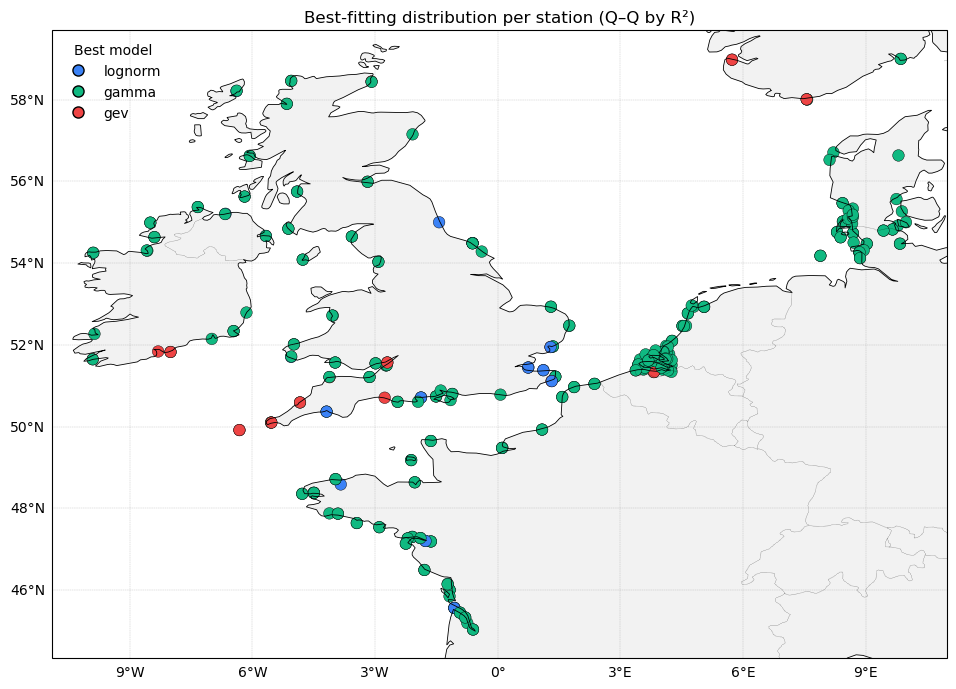

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import ListedColormap

# --- build arrays from your combined table ---
# expects df_all to have: latitude, longitude, best_model
lat = df_all["latitude"].values
lon = df_all["longitude"].values
best = df_all["best_model"].values

# Normalize labels: handle cases where best_model is numeric {0,1,2}
label_map_num = {0:"lognorm", 1:"gamma", 2:"gev"}
if np.issubdtype(best.dtype, np.number):
    best_labels = np.array([label_map_num.get(int(b), "unknown") if np.isfinite(b) else "unknown" for b in best])
else:
    best_labels = best.astype(str)

# Keep only valid points
valid = np.isfinite(lat) & np.isfinite(lon) & (best_labels != "nan")

lat = lat[valid]
lon = lon[valid]
best_labels = best_labels[valid]

# Unique classes (stable order)
classes = ["lognorm", "gamma", "gev"]
present = [c for c in classes if c in set(best_labels)]

# Map labels to integer indices for color mapping
class_to_idx = {c:i for i,c in enumerate(present)}
idx = np.array([class_to_idx.get(lbl, np.nan) for lbl in best_labels], dtype=float)
keep = np.isfinite(idx)
lat, lon, idx = lat[keep], lon[keep], idx[keep].astype(int)

# Colormap (up to 3 classes)
palette = ["#3b82f6", "#10b981", "#ef4444"]  # blue, green, red
cmap = ListedColormap([palette[class_to_idx[c]] for c in present])

# ---- make the map ----
proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(10, 7))
ax = plt.axes(projection=proj)

# Set extent with padding
xmin, xmax = float(np.nanmin(lon)), float(np.nanmax(lon))
ymin, ymax = float(np.nanmin(lat)), float(np.nanmax(lat))
pad_x = max(0.5, 0.05 * (xmax - xmin))
pad_y = max(0.5, 0.05 * (ymax - ymin))
ax.set_extent([xmin - pad_x, xmax + pad_x, ymin - pad_y, ymax + pad_y], crs=proj)

# Base layers
ax.add_feature(cfeature.LAND, facecolor="0.95")
ax.add_feature(cfeature.OCEAN, facecolor="white")
ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle=":")
gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.5, linestyle="--")
gl.right_labels = False; gl.top_labels = False

# Scatter
sc = ax.scatter(lon, lat, c=idx, cmap=cmap, s=70, edgecolor="k", linewidth=0.3, transform=proj)

# Legend
handles = [plt.Line2D([0],[0], marker='o', linestyle='', markersize=8,
                      markerfacecolor=cmap(i), markeredgecolor='k', label=lbl)
           for i, lbl in enumerate(present)]
ax.legend(handles=handles, title="Best model", loc="upper left", frameon=False)

ax.set_title("Best-fitting distribution per station (Q–Q by R²)")
plt.tight_layout()
plt.show()


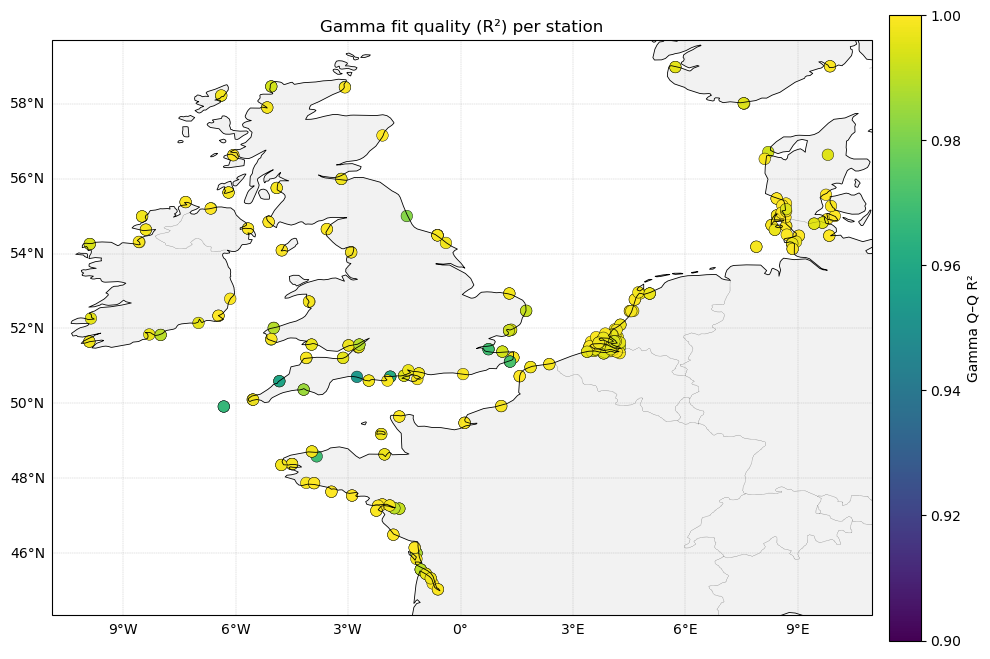

In [12]:
import numpy as np
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature

# Pull arrays
lat = df_all["latitude"].values
lon = df_all["longitude"].values
r2  = df_all["gamma_r2"].values.astype(float)

# Keep valid points
m = np.isfinite(lat) & np.isfinite(lon) & np.isfinite(r2)
lat = lat[m]; lon = lon[m]; r2 = r2[m]

# --- Cap legend range ---
vmin = 0.90   # lower bound of colorbar
vmax = 1.00   # upper bound of colorbar

proj = ccrs.PlateCarree()
fig = plt.figure(figsize=(10, 7))
ax = plt.axes(projection=proj)

# Extent with padding
xmin, xmax = float(np.nanmin(lon)), float(np.nanmax(lon))
ymin, ymax = float(np.nanmin(lat)), float(np.nanmax(lat))
pad_x = max(0.5, 0.05 * (xmax - xmin))
pad_y = max(0.5, 0.05 * (ymax - ymin))
ax.set_extent([xmin - pad_x, xmax + pad_x, ymin - pad_y, ymax + pad_y], crs=proj)

# Basemap
ax.add_feature(cfeature.LAND, facecolor="0.95")
ax.add_feature(cfeature.OCEAN, facecolor="white")
ax.add_feature(cfeature.COASTLINE, linewidth=0.6)
ax.add_feature(cfeature.BORDERS, linewidth=0.3, linestyle=":")
gl = ax.gridlines(draw_labels=True, linewidth=0.3, color="gray", alpha=0.5, linestyle="--")
gl.right_labels = False; gl.top_labels = False

# Scatter plot
sc = ax.scatter(lon, lat, c=r2, s=70, cmap="viridis", vmin=vmin, vmax=vmax,
                edgecolor="k", linewidth=0.3, transform=proj)

cb = plt.colorbar(sc, ax=ax, fraction=0.036, pad=0.02)
cb.set_label("Gamma Q–Q R²")
cb.set_ticks(np.linspace(vmin, vmax, 6))   # nice scale e.g. 0.75, 0.80, ...

ax.set_title("Gamma fit quality (R²) per station")
plt.tight_layout()
plt.show()


In [31]:
import os, ast, warnings
import scipy.stats as st
def parse_params(s):
    if isinstance(s, (tuple, list, np.ndarray)): 
        return tuple(s) 
    if not isinstance(s, str) or s.strip()=="" or s.strip().lower()=="nan": 
        return None 
    try: return tuple(ast.literal_eval(s)) 
    except Exception: return None

def pick_three_stations(df_all): 
    m = df_all["gamma_params"].apply(parse_params).notnull() & np.isfinite(df_all["gamma_r2"].astype(float)) 
    cand = df_all.loc[m, "station_index"].astype(int).values # fallback: just pick first 3 distinct if there are many
    return list(cand[:3])

TIME_DIMS = {"time", "valid_time"}

def get_series(ds, var, i, stn_dim="station"):
    da = ds[var]
    # Case 1: has the expected station dim
    if stn_dim in da.dims:
        return da.isel({stn_dim: int(i)}).values
    # Case 2: has some other non-time dim (e.g. 'stations', 'site')
    other_dims = [d for d in da.dims if d not in TIME_DIMS]
    if other_dims:
        return da.isel({other_dims[0]: int(i)}).values
    # Case 3: no station-like dim → treat as single-station series
    if i != 0:
        raise ValueError(f"No station dimension in ds; only i=0 is valid (got i={i}).")
    return da.values

# --- helper to safely extract a station's time series no matter the dimension name ---
TIME_DIMS = {"time", "valid_time"}

def get_series(ds, var, i, stn_dim="station"):
    """
    Return the 1D time series for station index i.

    Works whether the dataset has:
      - a dimension called 'station'
      - another non-time dimension holding stations
      - or no station dimension at all (single-station case)
    """
    da = ds[var]

    # Case 1: expected station dimension exists
    if stn_dim in da.dims:
        return da.isel({stn_dim: int(i)}).values

    # Case 2: find any other non-time dimension → assume this is station dimension
    other_dims = [d for d in da.dims if d not in TIME_DIMS]
    if other_dims:
        return da.isel({other_dims[0]: int(i)}).values

    # Case 3: no station-like dimension → entire array is single station
    if i != 0:
        raise ValueError(f"No station dimension found; only i=0 valid (you requested i={i})")
    return da.values



# ---------------- config ---------------- 
VAR_NAME = "residual" 
STN_DIM = "station" 
MIN_N = 20 
OUTPUT_DIR = "/Users/lb962/Documents/GitHub/ESL/data/Q-Q_results" 
REL_TOL = 0.10 # within 10% on all params 
N_TRIALS = 30 # trials per N N_START = 1000 # start with 1000 points 
N_STEP = 10000 # then every 10,000 points 
RANDOM_SEED = 42 
os.makedirs(OUTPUT_DIR, exist_ok=True) 
rng = np.random.default_rng(RANDOM_SEED)

In [32]:
ds = ds.rename({"time": "station"})  

ValueError: cannot rename 'time' because it is not a variable or dimension in this dataset

Station 82 label 216: first N (positives) within 10% = 10000; saved /Users/lb962/Documents/GitHub/ESL/data/Q-Q_results/gamma_convergence_incremental_POSONLY_station_216.csv


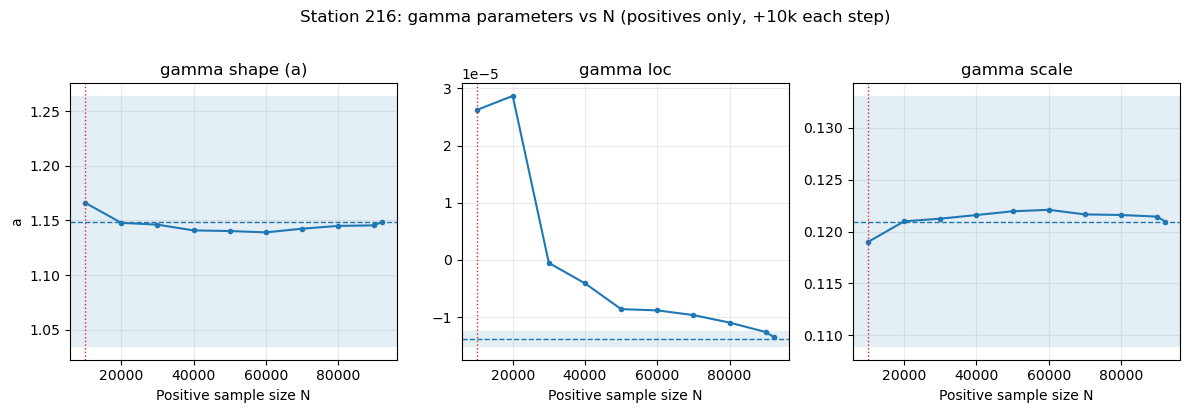

Saved plot: /Users/lb962/Documents/GitHub/ESL/data/Q-Q_results/gamma_convergence_incremental_POSONLY_station_216.png
Station 264 label 570: first N (positives) within 10% = 10000; saved /Users/lb962/Documents/GitHub/ESL/data/Q-Q_results/gamma_convergence_incremental_POSONLY_station_570.csv


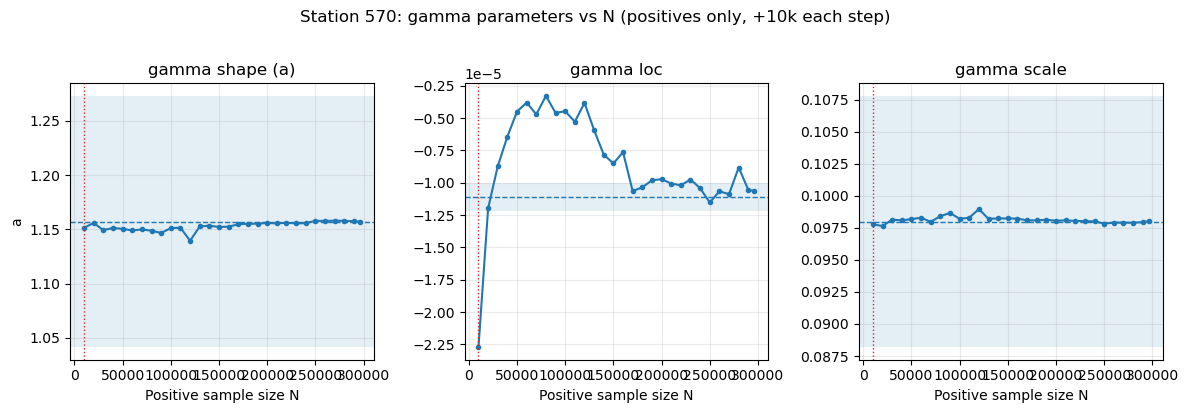

Saved plot: /Users/lb962/Documents/GitHub/ESL/data/Q-Q_results/gamma_convergence_incremental_POSONLY_station_570.png
Station 131 label 376: first N (positives) within 10% = 10000; saved /Users/lb962/Documents/GitHub/ESL/data/Q-Q_results/gamma_convergence_incremental_POSONLY_station_376.csv


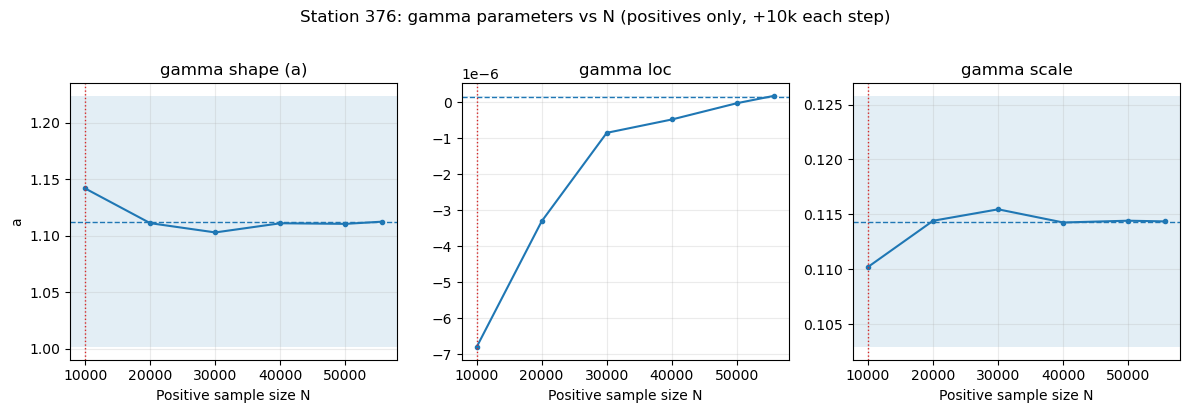

Saved plot: /Users/lb962/Documents/GitHub/ESL/data/Q-Q_results/gamma_convergence_incremental_POSONLY_station_376.png


In [33]:
# ---- make experiment consistent with your first fitting code ----
REL_TOL     = 0.10
N_START     = 10_000          # start with 10k POSITIVE samples
N_STEP      = 10_000          # add 10k POSITIVE samples each time
RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)
stations = pick_three_stations(df_all)

def _gamma_fit_vector(x_pos):
    """Identical fitting behavior: gamma.fit on x>0, free (a, loc, scale)."""
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        return st.gamma.fit(x_pos)  # (a, loc, scale)

for i in stations:
    # raw series
    x = get_series(ds, VAR_NAME, i, stn_dim=STN_DIM)
    x = x[np.isfinite(x)]

    # --- make it identical to your first code: restrict to positive values for gamma ---
    x_pos = x[x > 0]
    n_pos_total = x_pos.size
    if n_pos_total < max(MIN_N, N_START):
        print(f"Station {i}: too few positive points ({n_pos_total}). Skipping.")
        continue

    # reference params from the first run (CSV/df_all) — already gamma-on-positives
    row = df_all.loc[df_all["station_index"] == int(i)]
    if row.empty:
        print(f"Station {i}: no df_all row. Skipping.")
        continue
    ref = parse_params(row.iloc[0].get("gamma_params", None))
    if ref is None or not np.all(np.isfinite(ref)):
        print(f"Station {i}: invalid reference gamma params. Skipping.")
        continue
    a_ref, loc_ref, scale_ref = map(float, ref)

    # single random permutation (reproducible)
    idx_perm = rng.permutation(n_pos_total)
    x_pos_perm = x_pos[idx_perm]

    # POSITIVE-sample Ns: 10k, 20k, ...
    Ns = list(range(N_START, n_pos_total + 1, N_STEP))
    if Ns[-1] != n_pos_total:
        Ns.append(n_pos_total)

    rows = []
    first_N_within = None
    # eps used for robust relative error (avoid blow-up if loc≈0)
    eps = max(1e-8, 0.01 * float(np.nanstd(x_pos)) if np.isfinite(np.nanstd(x_pos)) else 1e-6)

    for N in Ns:
        if N < MIN_N:
            continue
        x_sub = x_pos_perm[:N]       # <-- ONLY positives, like first code
        a_est, loc_est, scale_est = map(float, _gamma_fit_vector(x_sub))

        rel_a     = abs(a_est    - a_ref)    / max(abs(a_ref),    eps)
        rel_loc   = abs(loc_est  - loc_ref)  / max(abs(loc_ref),  eps)
        rel_scale = abs(scale_est- scale_ref)/ max(abs(scale_ref),eps)
        within = (rel_a <= REL_TOL) and (rel_loc <= REL_TOL) and (rel_scale <= REL_TOL)
        if (first_N_within is None) and within:
            first_N_within = N

        rows.append({
            "station_index": int(i),
            "N_pos": int(N),           # number of positive samples used
            "a": a_est, "loc": loc_est, "scale": scale_est,
            "relerr_a": rel_a, "relerr_loc": rel_loc, "relerr_scale": rel_scale,
            "within_10pct": within
        })

    df_s = pd.DataFrame(rows)
    label = str(row.iloc[0]["station_label"]) if "station_label" in row and pd.notnull(row.iloc[0]["station_label"]) else str(int(i))

    out_csv = os.path.join(OUTPUT_DIR, f"gamma_convergence_incremental_POSONLY_station_{label}.csv")
    df_s.to_csv(out_csv, index=False)
    print(f"Station {i} label {label}: first N (positives) within 10% = {first_N_within}; saved {out_csv}")

    # ---- plots (now consistent with first fit) ----
    fig, axes = plt.subplots(1, 3, figsize=(12,4), sharex=True)
    ax1, ax2, ax3 = axes

    ax1.plot(df_s["N_pos"], df_s["a"], marker="o", ms=3)
    ax1.axhline(a_ref, linestyle="--", linewidth=1)
    ax1.axhspan(a_ref*(1-REL_TOL), a_ref*(1+REL_TOL), alpha=0.12)
    if first_N_within: ax1.axvline(first_N_within, color="tab:red", linestyle=":", linewidth=1)
    ax1.set_title("gamma shape (a)"); ax1.set_ylabel("a")

    ax2.plot(df_s["N_pos"], df_s["loc"], marker="o", ms=3)
    ax2.axhline(loc_ref, linestyle="--", linewidth=1)
    ax2.axhspan(loc_ref - abs(loc_ref)*REL_TOL, loc_ref + abs(loc_ref)*REL_TOL, alpha=0.12)
    if first_N_within: ax2.axvline(first_N_within, color="tab:red", linestyle=":", linewidth=1)
    ax2.set_title("gamma loc")

    ax3.plot(df_s["N_pos"], df_s["scale"], marker="o", ms=3)
    ax3.axhline(scale_ref, linestyle="--", linewidth=1)
    ax3.axhspan(scale_ref*(1-REL_TOL), scale_ref*(1+REL_TOL), alpha=0.12)
    if first_N_within: ax3.axvline(first_N_within, color="tab:red", linestyle=":", linewidth=1)
    ax3.set_title("gamma scale")

    for ax in axes:
        ax.set_xlabel("Positive sample size N")
        ax.grid(alpha=0.25)

    fig.suptitle(f"Station {label}: gamma parameters vs N (positives only, +10k each step)", y=1.02)
    plt.tight_layout()
    png_path = os.path.join(OUTPUT_DIR, f"gamma_convergence_incremental_POSONLY_station_{label}.png")
    plt.savefig(png_path, dpi=150)
    plt.show()
    print(f"Saved plot: {png_path}")


In [26]:

# ---- plots ---------------------------------------------------------------------
# replace your earlier lon/lat line(s) with this:
lon, lat = get_station_coords(ds, lon_name="station_longitude", lat_name="station_latitude")
# 1) Best distribution (categorical)
best_vals = results["best_dist"]
labels = ["lognorm", "gamma", "GEV"]
if USE_QUICK_MAP:
    # quick_map doesn't do categorical, so show as 0/1/2 index with a legend-based map
    # use our helper for categorical display
    map_values_cartopy(lon, lat, best_vals, title="Best-fit distribution by Q–Q (max R²)",
                       categorical=True, classes=np.array([0,1,2]),
                       class_labels=labels)
else:
    map_values_cartopy(lon, lat, best_vals, title="Best-fit distribution by Q–Q (max R²)",
                       categorical=True, classes=np.array([0,1,2]),
                       class_labels=labels)

# 2) Continuous R² maps (one per distribution)
for name in ["lognorm", "gamma", "gev"]:
    vals = results[f"{name}_r2"]
    title = f"Q–Q R² vs {name}"
    cbar = "Q–Q R²"
    if USE_QUICK_MAP:
        # Clamp display between 0 and 1
        vals_plot = vals.copy()
        # quick_map signature: quick_map(vals, title, cbarlabel)
        try:
            quick_map(vals_plot, title, cbar)
        except Exception:
            # fallback to explicit cartopy function
            map_values_cartopy(lon, lat, vals, title=title, cbarlabel=cbar, vmin=0.0, vmax=1.0)
    else:
        map_values_cartopy(lon, lat, vals, title=title, cbarlabel=cbar, vmin=0.0, vmax=1.0)

# Optional: make a tidy DataFrame of metrics to save/inspect
qq_df = pd.DataFrame({
    "lognorm_r2": results["lognorm_r2"],
    "gamma_r2":   results["gamma_r2"],
    "gev_r2":     results["gev_r2"],
    "lognorm_rmse": results["lognorm_rmse"],
    "gamma_rmse":   results["gamma_rmse"],
    "gev_rmse":     results["gev_rmse"],
    "best_dist_idx": results["best_dist"],
    "best_dist_label": [labels[int(i)] if np.isfinite(i) else np.nan for i in results["best_dist"]],
})
qq_df.insert(0, "station_index", np.arange(n_stations))
print(qq_df.head())

ValueError: No valid points to plot.

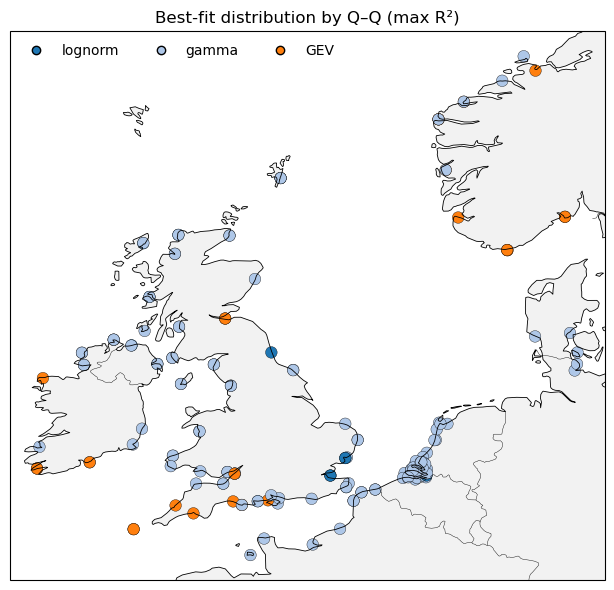

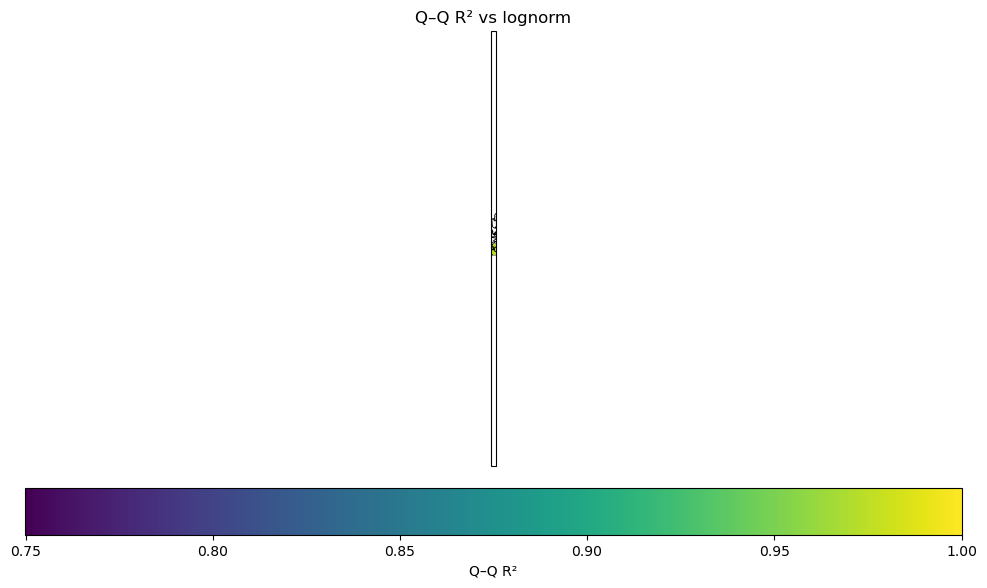

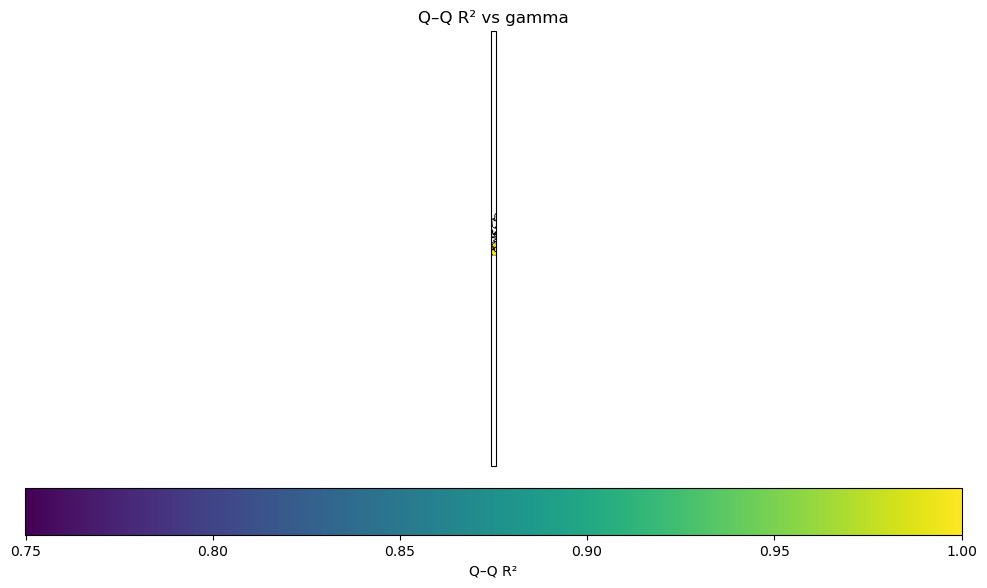

ValueError: No valid points to plot.

In [24]:
# --- fixed color scale for all R² maps ---
R2_MIN, R2_MAX = 0.75, 1.0

# Best-fit (categorical) stays the same
map_values_cartopy(
    lon, lat, best_vals,
    title="Best-fit distribution by Q–Q (max R²)",
    categorical=True, classes=np.array([0,1,2]),
    class_labels=["lognorm","gamma","GEV"]
)

# Continuous R² maps with consistent scale
for name in ["lognorm", "gamma", "gev"]:
    vals = results[f"{name}_r2"]
    # clip just for visualization (NaNs remain NaN and won't plot)
    vals_plot = np.clip(vals, R2_MIN, R2_MAX)
    map_values_cartopy(
        lon, lat, vals_plot,
        title=f"Q–Q R² vs {name}",
        cbarlabel="Q–Q R²",
        vmin=R2_MIN, vmax=R2_MAX
    )


   station_index  lognorm_r2  lognorm_rmse  gamma_r2  gamma_rmse    gev_r2  \
0              0    0.972736      0.015069  0.995834    0.005891  0.998406   
1              1    0.970537      0.017874  0.995450    0.007024  0.998676   
2              2    0.984853      0.015883  0.956114    0.027035  0.967248   
3              3    0.981149      0.013892  0.994925    0.007208  0.997521   
4              4    0.976614      0.017949  0.992412    0.010224  0.998850   

   gev_rmse   fisk_r2  fisk_rmse   burr_r2  burr_rmse  gpd95_r2  gpd95_rmse  \
0  0.005309  0.874212   0.032368  0.993497   0.007360  0.923203    0.036842   
1  0.005355  0.868438   0.037769  0.988447   0.011192  0.704782    0.079969   
2  0.028466  0.973114   0.021161  0.976736   0.019684  0.696041    0.086719   
3  0.007746  0.905154   0.031162  0.997446   0.005113  0.542123    0.105282   
4  0.006167  0.893348   0.038331  0.996706   0.006736  0.903030    0.056622   

   best_dist_idx best_dist_label  
0            2.0     

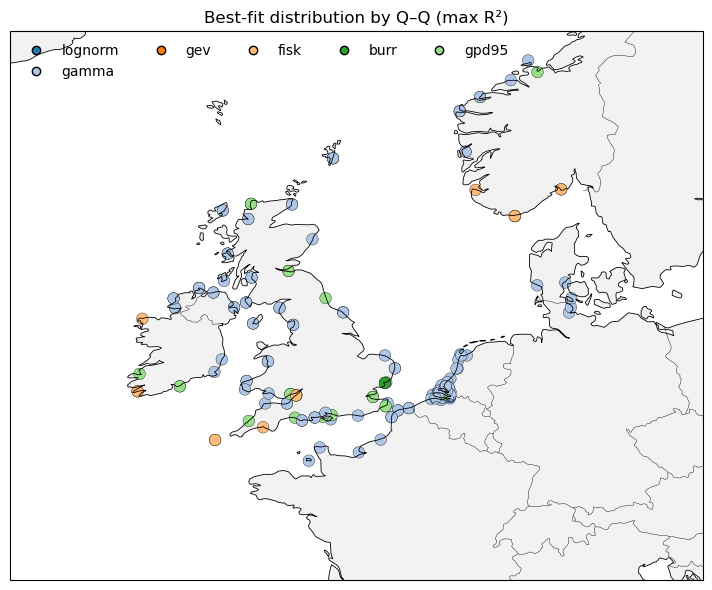

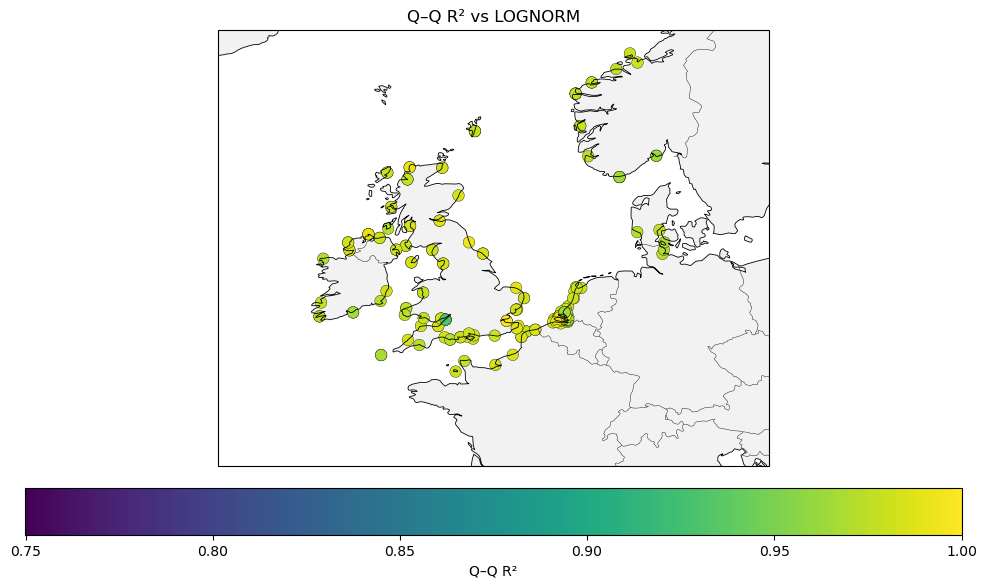

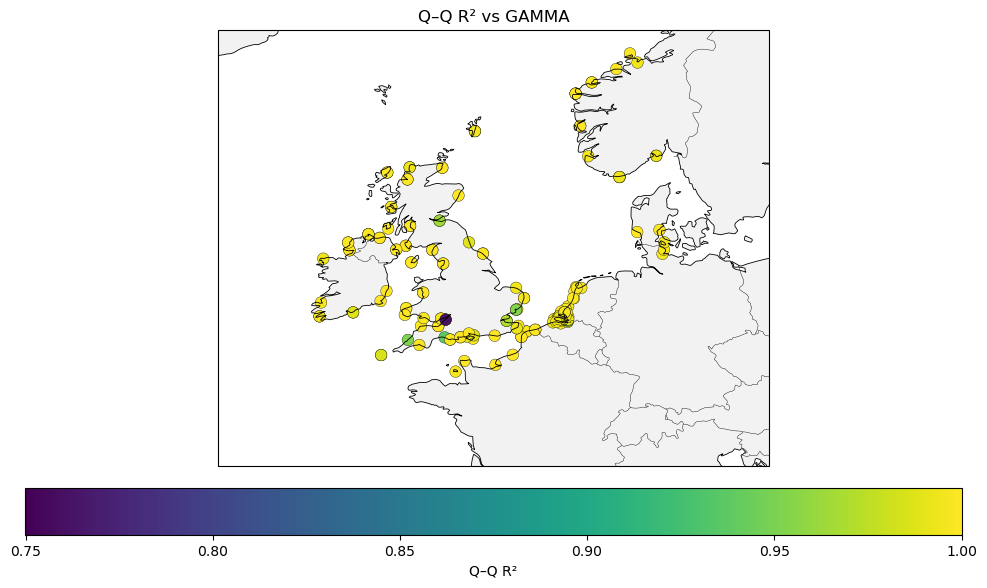

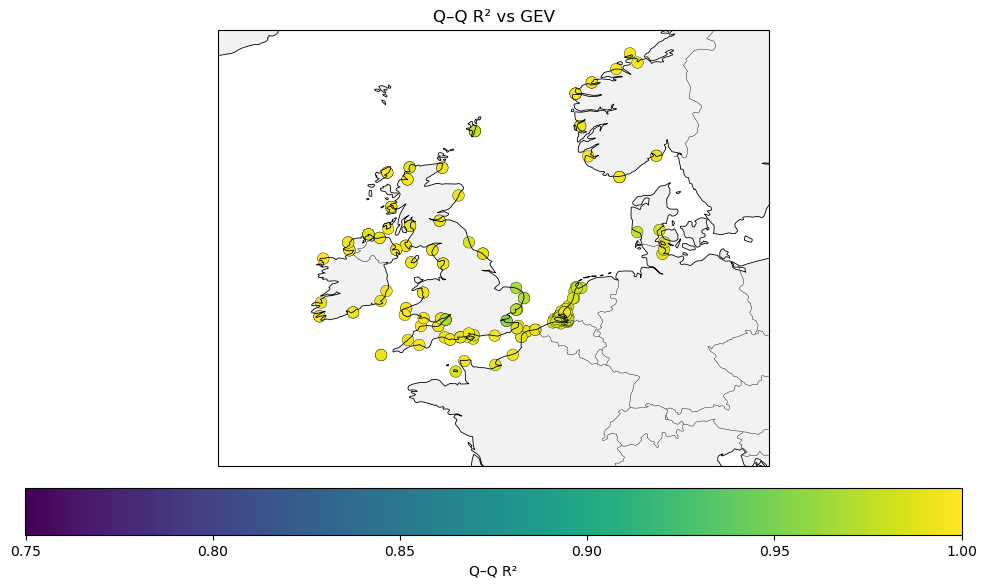

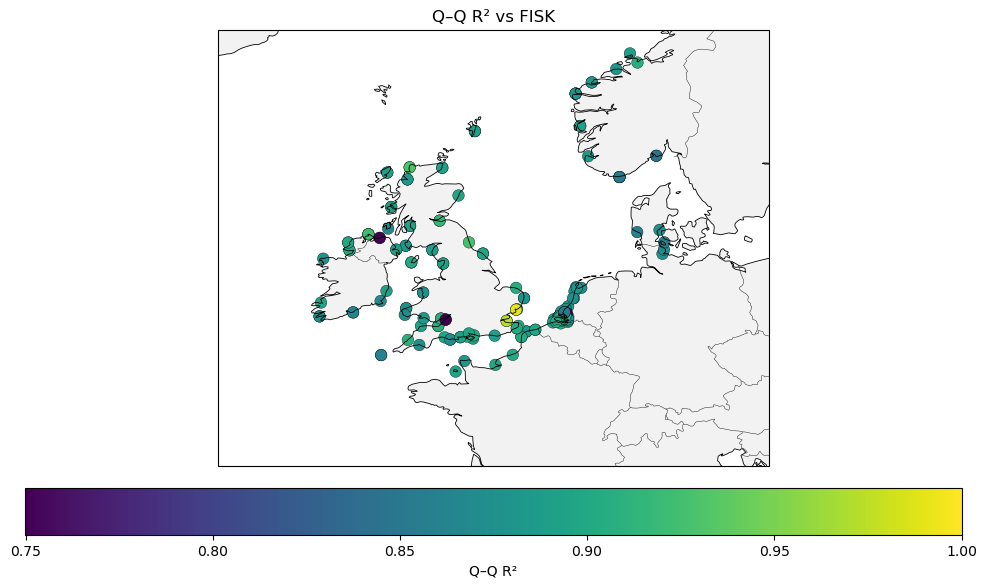

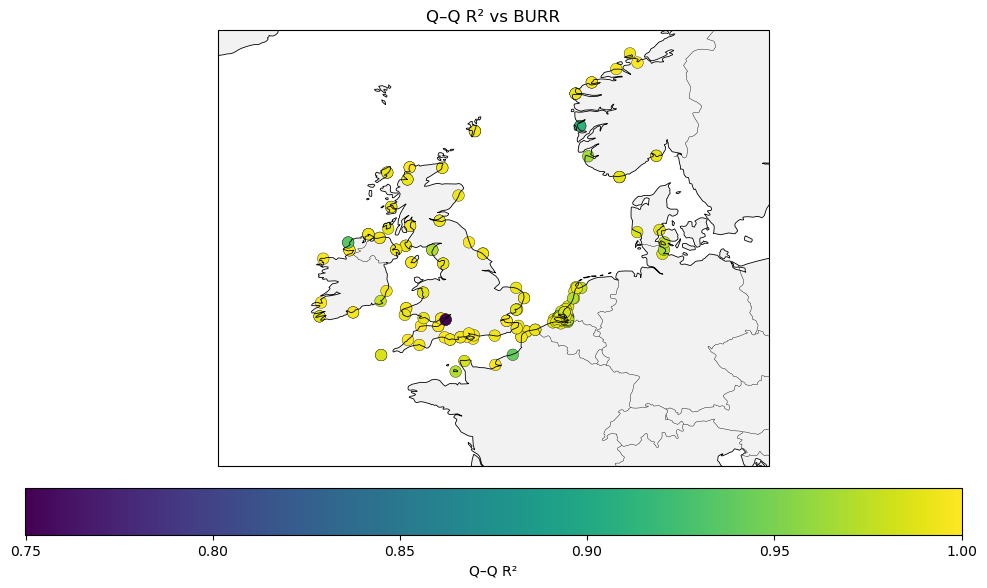

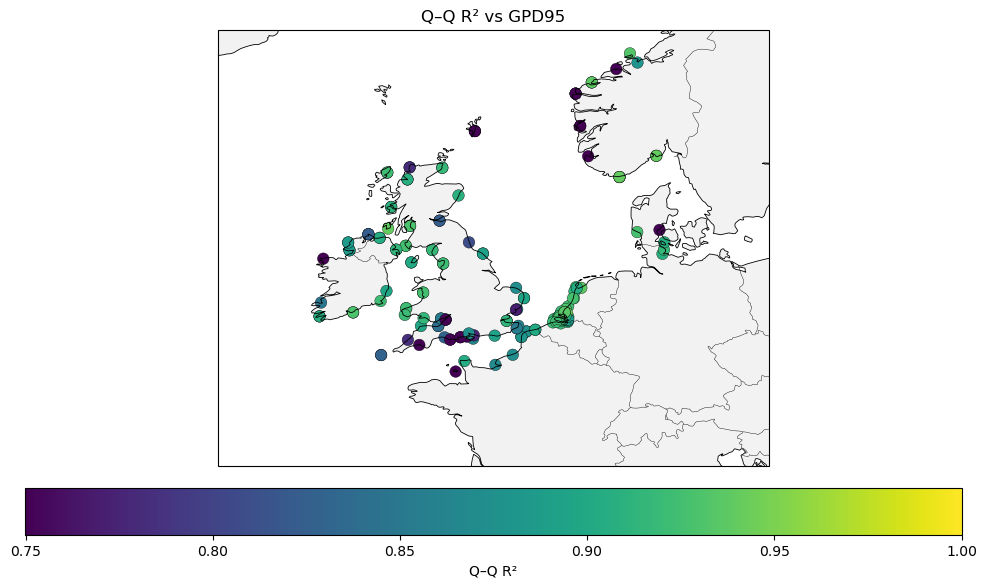

In [27]:
# ===============================================================
# Per-station Q–Q fits for surge-relevant tails + Cartopy maps
# Families: lognorm, gamma, GEV, Fisk (log-logistic), Burr XII, GPD (POT 95%)
# ===============================================================
import numpy as np
import pandas as pd
import xarray as xr
import scipy.stats as st
from numpy.linalg import lstsq
import warnings

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cfeature
from matplotlib.colors import ListedColormap

# ---------------------------------------------------------------
# CONFIG
# ---------------------------------------------------------------
VAR_NAME = "residual"     # the variable to analyze, shape (station, time)
MIN_N = 20                # minimum samples to attempt a fit
PROBS = np.linspace(0.01, 0.99, 99)  # quantile levels for Q–Q
R2_MIN, R2_MAX = 0.75, 1.0           # fixed color scale for R² plots
EXTENT = [-15, 15, 45, 65]           # [lon_min, lon_max, lat_min, lat_max]
LON_NAME_DEFAULT = "station_longitude"
LAT_NAME_DEFAULT = "station_latitude"

# Parametric families (domain-positive where required)
DISTRIBUTIONS = [
    ("lognorm", st.lognorm, {"require_pos": True}),      # Lognormal
    ("gamma",   st.gamma,   {"require_pos": True}),      # Gamma
    ("gev",     st.genextreme, {"require_pos": False}),  # GEV (SciPy's genextreme)
    ("fisk",    st.fisk,    {"require_pos": True}),      # Log-logistic
    ("burr",    st.burr,    {"require_pos": True}),      # Burr XII
]

# GPD POT options
GPD_THRESHOLD_Q = 0.95  # 95th percentile threshold for exceedances (POT)

# ---------------------------------------------------------------
# Helpers
# ---------------------------------------------------------------
def get_station_coords(ds, lon_name=LON_NAME_DEFAULT, lat_name=LAT_NAME_DEFAULT):
    """
    Return (lon, lat) arrays of shape (station,).
    Defaults to 'station_longitude' and 'station_latitude'.
    """
    if lon_name not in ds or lat_name not in ds:
        # Helpful diagnostic
        avail = [v for v in ds.variables if "station" in getattr(ds[v], "dims", ())]
        raise ValueError(
            f"Could not find lon/lat as '{lon_name}'/'{lat_name}'. "
            f"Station-dimension variables available: {avail}"
        )
    lon = np.asarray(ds[lon_name].values, float)
    lat = np.asarray(ds[lat_name].values, float)
    if np.nanmax(lon) > 180:
        lon = ((lon + 180) % 360) - 180
    return lon, lat

def map_values_cartopy(lon, lat, vals, title="", cbarlabel="", vmin=None, vmax=None,
                       categorical=False, classes=None, class_labels=None, extent=None, ticks=None):
    proj = ccrs.Robinson()
    data_crs = ccrs.PlateCarree()
    valid = np.isfinite(lon) & np.isfinite(lat) & np.isfinite(vals)
    if valid.sum() == 0:
        raise ValueError("No valid points to plot.")

    fig = plt.figure(figsize=(12, 6))
    ax = plt.axes(projection=proj)
    if extent is not None:
        ax.set_extent(extent, crs=data_crs)
    else:
        ax.set_global()

    ax.coastlines(linewidth=0.6)
    ax.add_feature(cfeature.BORDERS.with_scale("50m"), linewidth=0.3)
    ax.add_feature(cfeature.LAND.with_scale("50m"), facecolor="0.95")
    ax.add_feature(cfeature.OCEAN.with_scale("50m"), facecolor="white")

    if categorical:
        if classes is None:
            classes = np.unique(vals[valid].astype(int))
        n = len(classes)
        cmap = ListedColormap(plt.get_cmap("tab20").colors[:n])
        # remap classes to 0..n-1
        class_to_i = {c: i for i, c in enumerate(classes)}
        idx = np.full(vals.shape, np.nan)
        for c, i in class_to_i.items():
            idx[vals == c] = i
        ax.scatter(lon[valid], lat[valid], c=idx[valid],
                   transform=data_crs, s=70, cmap=cmap,
                   edgecolor="k", linewidth=0.25)
        labels = class_labels if class_labels is not None else [str(c) for c in classes]
        handles = [plt.Line2D([0],[0], marker='o', linestyle='',
                              markerfacecolor=cmap(i), markeredgecolor='k',
                              label=labels[j]) for j, i in enumerate(range(n))]
        ax.legend(handles=handles, loc="upper left", frameon=False, ncol=min(5, n))
    else:
        sc = ax.scatter(lon[valid], lat[valid], c=vals[valid],
                        transform=data_crs, s=70, cmap="viridis",
                        vmin=vmin, vmax=vmax,
                        edgecolor="k", linewidth=0.25)
        cb = plt.colorbar(sc, orientation="horizontal", pad=0.04, shrink=0.8)
        cb.set_label(cbarlabel)
        if ticks is not None:
            cb.set_ticks(ticks)

    ax.set_title(title)
    plt.tight_layout()
    plt.show()

def qq_metrics(x, dist, params, probs=PROBS):
    """
    Q–Q: y (empirical quantiles) vs x_theor (theoretical quantiles),
    fit y ~ a*x + b, return (slope, intercept, R2, RMSE).
    """
    y = np.quantile(x, probs)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        x_theor = dist.ppf(probs, *params)
    m = np.isfinite(x_theor) & np.isfinite(y)
    if m.sum() < 3:
        return (np.nan, np.nan, np.nan, np.nan)
    X = np.column_stack([x_theor[m], np.ones(m.sum())])
    a, b = lstsq(X, y[m], rcond=None)[0]
    yhat = a * x_theor[m] + b
    ss_res = np.sum((y[m] - yhat) ** 2)
    ss_tot = np.sum((y[m] - y[m].mean()) ** 2)
    r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan
    rmse = np.sqrt(np.mean((y[m] - yhat) ** 2))
    return (a, b, r2, rmse)

def fit_params(dist_name, dist_obj, x):
    """
    Fit parameters with domain guards.
    lognorm/gamma/fisk/burr require x>0; others allow full real line (as per SciPy).
    """
    require_pos = dist_name in ("lognorm", "gamma", "fisk", "burr")
    x_fit = x[x > 0] if require_pos else x
    if x_fit.size < MIN_N:
        return None, None
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            params = dist_obj.fit(x_fit)  # (shape(s), loc, scale)
        return x_fit, params
    except Exception:
        return None, None

def fit_gpd_pot(x, u_quant=0.95, min_exceed=MIN_N):
    """
    Fit Generalized Pareto to exceedances over threshold u = quantile(u_quant).
    Returns (x_exceed, params, u). If not enough exceedances, returns (None,None,None).
    SciPy's genpareto: shape=c, loc=loc, scale=scale for exceedances y = x - u.
    """
    if x.size < MIN_N:
        return None, None, None
    u = np.nanquantile(x, u_quant)
    y = x[x > u] - u
    y = y[np.isfinite(y)]
    if y.size < min_exceed:
        return None, None, None
    try:
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            params = st.genpareto.fit(y)
        return y, params, u
    except Exception:
        return None, None, None

# ---------------------------------------------------------------
# Main computation
# ---------------------------------------------------------------
n_stations = ds.sizes["station"]

# Prepare results dict dynamically for all families + GPD95
results = {}
for (name, _, _) in DISTRIBUTIONS:
    results[f"{name}_r2"] = np.full(n_stations, np.nan)
    results[f"{name}_rmse"] = np.full(n_stations, np.nan)
results["gpd95_r2"] = np.full(n_stations, np.nan)
results["gpd95_rmse"] = np.full(n_stations, np.nan)
results["best_dist"] = np.full(n_stations, np.nan)  # index into all_names

# Family ordering for legends and "best"
all_names = [name for (name, _, _) in DISTRIBUTIONS] + ["gpd95"]

with warnings.catch_warnings():
    warnings.simplefilter("ignore", category=RuntimeWarning)

    for i in range(n_stations):
        x_all = ds[VAR_NAME].isel(station=i).values
        x_all = x_all[np.isfinite(x_all)]
        if x_all.size < MIN_N:
            continue

        r2s = []

        # Parametric families
        for (name, dist_obj, meta) in DISTRIBUTIONS:
            x_fit, params = fit_params(name, dist_obj, x_all)
            if x_fit is None:
                results[f"{name}_r2"][i]   = np.nan
                results[f"{name}_rmse"][i] = np.nan
                r2s.append(np.nan)
                continue
            try:
                _, _, r2, rmse = qq_metrics(x_fit, dist_obj, params, probs=PROBS)
            except Exception:
                r2 = rmse = np.nan
            results[f"{name}_r2"][i]   = r2
            results[f"{name}_rmse"][i] = rmse
            r2s.append(r2)

        # GPD POT at 95%
        y_ex, gpd_params, u = fit_gpd_pot(x_all, u_quant=GPD_THRESHOLD_Q, min_exceed=MIN_N)
        if y_ex is not None:
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                x_theor = st.genpareto.ppf(PROBS, *gpd_params) + u
            y_emp = np.quantile(x_all, PROBS)
            m = np.isfinite(x_theor) & np.isfinite(y_emp)
            if m.sum() >= 3:
                X = np.column_stack([x_theor[m], np.ones(m.sum())])
                a, b = lstsq(X, y_emp[m], rcond=None)[0]
                yhat = a * x_theor[m] + b
                ss_res = np.sum((y_emp[m] - yhat) ** 2)
                ss_tot = np.sum((y_emp[m] - y_emp[m].mean()) ** 2)
                r2 = 1.0 - ss_res / ss_tot if ss_tot > 0 else np.nan
                rmse = np.sqrt(np.mean((y_emp[m] - yhat) ** 2))
            else:
                r2 = rmse = np.nan
        else:
            r2 = rmse = np.nan

        results["gpd95_r2"][i]   = r2
        results["gpd95_rmse"][i] = rmse
        r2s.append(r2)

        # Best-by-R² index
        if np.isfinite(r2s).any():
            results["best_dist"][i] = int(np.nanargmax(r2s))

# ---------------------------------------------------------------
# Build a tidy table (optional)
# ---------------------------------------------------------------
qq_df_cols = {}
for name in all_names:
    qq_df_cols[f"{name}_r2"] = results[f"{name}_r2"]
    # rmse for gpd95 present; for safety:
    qq_df_cols[f"{name}_rmse"] = results.get(f"{name}_rmse", np.full(n_stations, np.nan))

qq_df = pd.DataFrame(qq_df_cols)
qq_df.insert(0, "station_index", np.arange(n_stations))
qq_df["best_dist_idx"] = results["best_dist"]
qq_df["best_dist_label"] = [all_names[int(i)] if np.isfinite(i) else np.nan for i in results["best_dist"]]
print(qq_df.head())

# ---------------------------------------------------------------
# PLOTTING
# ---------------------------------------------------------------
# Get station coords (defaults to your known field names)
lon, lat = get_station_coords(ds)

# Best-fit categorical map
best_vals = results["best_dist"]
map_values_cartopy(
    lon, lat, best_vals,
    title="Best-fit distribution by Q–Q (max R²)",
    categorical=True,
    classes=np.arange(len(all_names)),
    class_labels=all_names,
    extent=EXTENT
)

# Continuous R² maps (fixed color scale across all)
ticks = np.linspace(R2_MIN, R2_MAX, 6)
for name in all_names:
    vals = results[f"{name}_r2"]
    vals_plot = np.clip(vals, R2_MIN, R2_MAX)  # clip for visualization
    map_values_cartopy(
        lon, lat, vals_plot,
        title=f"Q–Q R² vs {name.upper()}",
        cbarlabel="Q–Q R²",
        vmin=R2_MIN, vmax=R2_MAX,
        extent=EXTENT,
        ticks=ticks
    )


In [31]:
qq_df.to_csv("/Users/lb962/Documents/GitHub/ESL/data/processed/q-qstations.csv")